# Aula 2 - Classificação de imagens de redes convolucionais


## Redes Neurais Convolucionais

Uma Rede Neural Convolucional (ConvNet / Convolutional Neural Network / CNN) é um algoritmo de Aprendizado Profundo que pode captar uma imagem de entrada, atribuir importância (pesos e vieses que podem ser aprendidos) a vários aspectos / objetos da imagem e ser capaz de diferenciar um do outro. O pré-processamento exigido em uma ConvNet é muito menor em comparação com outros algoritmos de classificação. Enquanto nos métodos primitivos os filtros são feitos à mão, com treinamento suficiente, as ConvNets têm a capacidade de aprender esses filtros / características. Em 1962, Hubel e Wiesel fizeram um experimento mostrando que alguns neurônios são ativados juntos quando expostos a algumas linhas ou curvas, conseguindo assim produzir o reconhecimento visual.
Essa é a basicamente a ideia principal de uma Rede Convolucional: filtrar linhas, curvas e bordas e em cada camada acrescida transformar essa filtragem em uma imagem mais complexa.

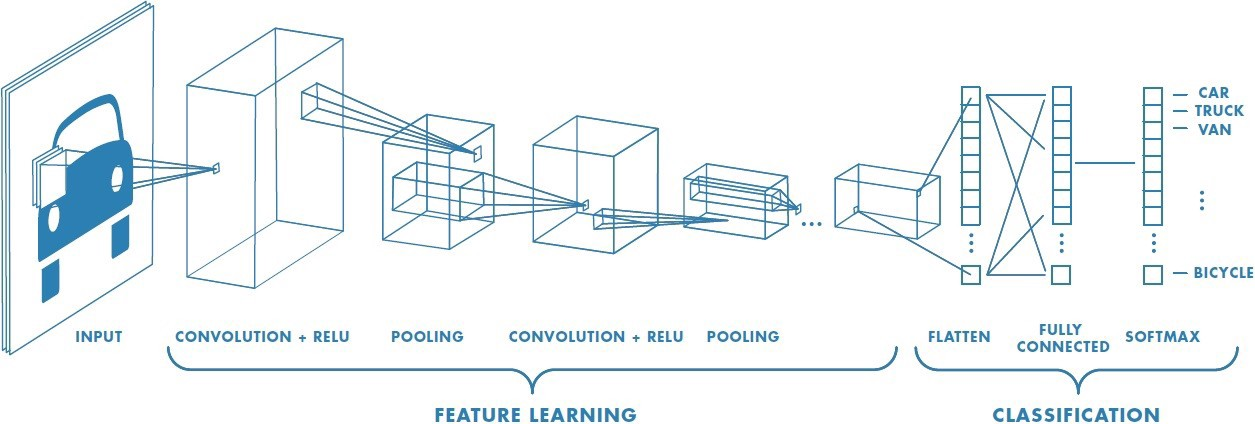

CNN X ANN

Uma imagem não é nada além de uma matriz de valores de pixels, certo? Então, por que não apenas achatar a imagem (por exemplo, converter uma matriz 3×3 em um vetor 9×1. Se a image é uma matriz, nenhum problema em converter em uma vetor) e alimentá-lo para um Perceptron Multi-Layer para fins de classificação? Na verdade não.

Em casos de imagens binárias extremamente básicas, o método pode mostrar uma pontuação de precisão média durante a previsão de classes, mas teria pouca ou nenhuma precisão quando se trata de imagens complexas com dependências de pixel por toda parte.

Uma ConvNet é capaz de capturar com sucesso as dependências espaciais e temporais em uma imagem através da aplicação de filtros relevantes. A arquitetura executa um melhor ajuste ao conjunto de dados da imagem devido à redução no número de parâmetros envolvidos e à capacidade de reutilização dos pesos. Em outras palavras, a rede pode ser treinada para entender melhor a sofisticação da imagem.

Quando falamos em reconhecimento/classificação de imagens, as entradas são usualmente matrizes tridimensionais com altura e largura (de acordo com as dimensões da imagem) e profundidade, determinada pela quantidade de canais de cores. Em geral as imagens utilizam três canais, RGB, com os valores de cada pixel.

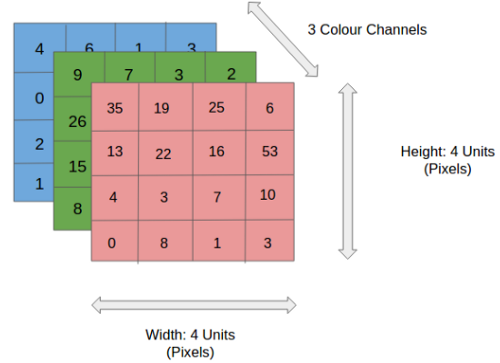

##Kernels Convolucionais

Um kernel é um filtro que utilizaremos em nossas imagens. Ele passará por toda a imagem, da esquerda para a direita, de cima para baixo, aplicando o produto da convolução. No final, teremos uma imagem filtrada.

No processamento de imagens, um kernel de convolução é uma matriz 2D usada para filtrar imagens. Também conhecido como uma matriz de convolução, um kernel de convolução é tipicamente um quadrado, matriz MxN, onde M e N são inteiros ímpares (por exemplo, 3 × 3, 5 × 5, 7 × 7 etc.). Veja a matriz de exemplo 3 × 3 fornecida abaixo.

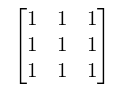

kernel de convolução 2D 3 × 3

Esses kernels podem ser usados para realizar operações matemáticas em cada pixel de uma imagem para obter o efeito desejado (como embaçar ou aumentar a nitidez de uma imagem). Mas por que você deseja desfocar uma imagem? Aqui estão dois motivos importantes:

Porque reduz certos tipos de ruído em uma imagem. Por esse motivo, o embaçamento costuma ser chamado de suavização.
Para remover uma distração do fundo, você pode desfocar intencionalmente partes de uma imagem, como é feito no modo 'Retrato', em câmeras de dispositivos móveis.
Por ser uma técnica de processamento fundamental em Visão Computacional, a filtragem de imagens com kernels tem muito mais aplicações.

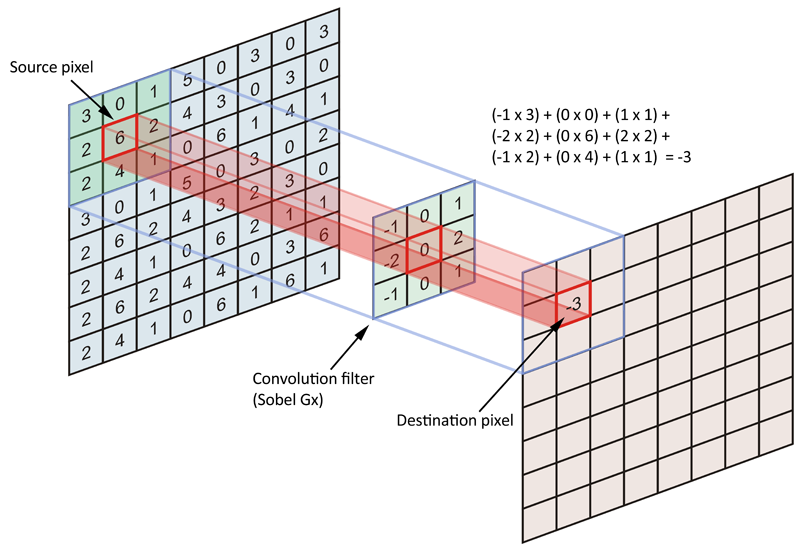

### Convoluções

As convoluções funcionam como filtros que enxergam pequenos quadrados e vão “escorregando” por toda a imagem captando os traços mais marcantes. Explicando melhor, com uma imagem 32x32x3 e um filtro que cobre uma área de 5x5 da imagem com movimento de 2 saltos (chamado de stride), o filtro passará pela imagem inteira, por cada um dos canais, formando no final um feature map ou activation map de 28x28x1.
A profundidade da saída de uma convolução é igual a quantidade de filtros aplicados. Quanto mais profundas são as camadas das convoluções, mais detalhados são os traços identificados com o activation map.
O filtro, que também é conhecido por kernel, é formado por pesos inicializados aleatoriamente, atualizando-os a cada nova entrada durante o processo de backpropagation. A pequena região da entrada onde o filtro é aplicado é chamada de receptive field.

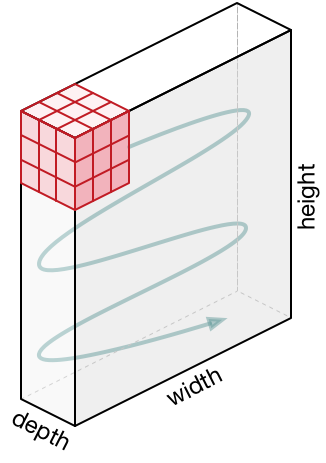

### Camada de Pooling

Uma camada de pooling serve para simplificar a informação da camada anterior. Assim como na convolução, é escolhida uma unidade de área, por exemplo 2x2, para transitar por toda a saída da camada anterior. A unidade é responsável por resumir a informação daquela área em um único valor. Se a saída da camada anterior for 24x24, a saída do pooling será 12x12. Além disso, é preciso escolher como será feita a sumarização. O método mais utilizado é o maxpooling, no qual apenas o maior número da unidade é passado para a saída. Essa sumarização de dados serve para diminuir a quantidade de pesos a serem aprendidos e também para evitar overfitting.

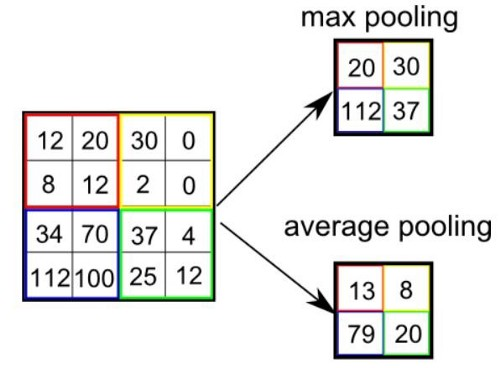

Camada Flatten


Essa camada normalmente é utilizada na divisão das 2 partes da CNN (extração de características / rede neural tradicional ). Ela basicamente opera uma transformação na matrix da imagem, alterando seu formato para um array. Por exemplo, uma imagem em grayscale de 28x28 será transformada para um array de 784 posições. A imagem abaixo ilustra essa operação.

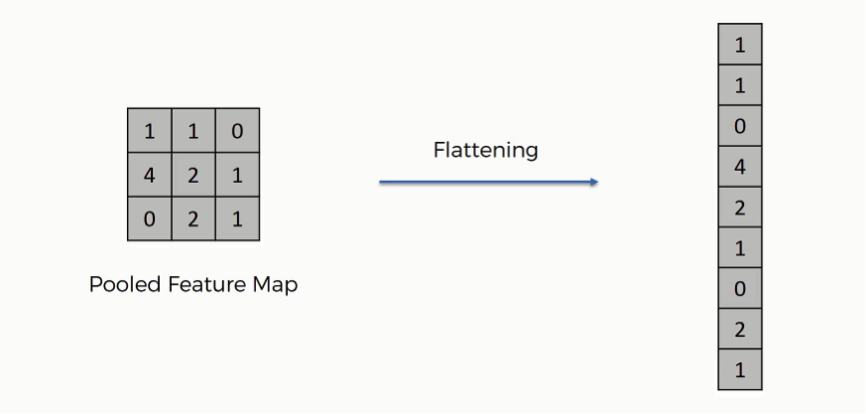

### Camada Densa

Ao final da rede é colocada uma camada Fully connected, onde sua entrada é a saída da camada anterior e sua saída são N neurônios, com N sendo a quantidade de classes do seu modelo para finalizar a classificação.

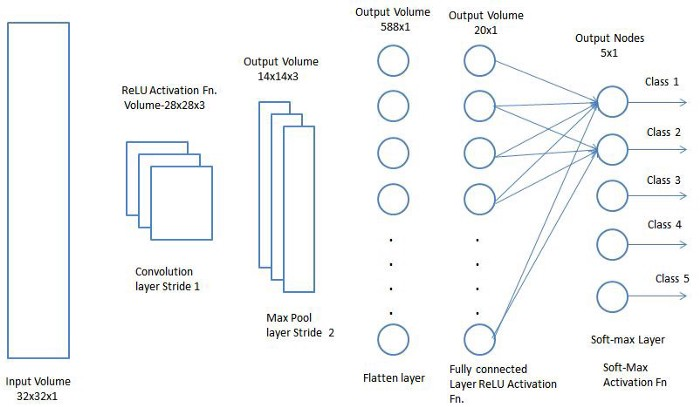

### Camada de Ativação final para a classificação

 - Sigmoide: Na camada de saída, a função sigmoide é útil para produzir probabilidades em problemas de classificação binária, já que seus resultados, na faixa de [0, 1], podem ser interpretados como a probabilidade de determinada instância pertencer ou não a determinada classe.

 - Softmax: Softmax é uma generalização da função sigmoide para casos não-binários. Ela não costuma ser aplicada às camadas escondidas da rede neural, mas sim na camada de saída de problemas de classificação multiclasse, já que sua característica é produzir valores no intervalo [0, 1] onde sua soma é igual a 1. Ou seja, num problema com 3 classes, por exemplo, a função softmax vai produzir 3 valores, que somam 1, onde cada valor representa a probabilidade da instância pertencer a uma das 3 possíveis classes.

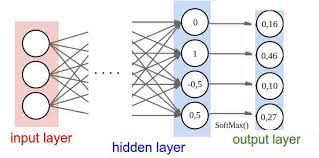

Link para acessar o dataset: https://drive.google.com/drive/folders/1_jfLD8yjmbEexfFnvn9yOcb6DmPkKAR9?usp=sharing

In [ ]:
!pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 89.1 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
import rasterio
import pandas as pd
from pylab import rcParams
import matplotlib
matplotlib.rcParams['axes.labelsize'] = 14
matplotlib.rcParams['xtick.labelsize'] = 14
matplotlib.rcParams['ytick.labelsize'] = 12
matplotlib.rcParams['text.color'] = 'k'
import seaborn as sns
plt.style.use('fivethirtyeight')
rcParams['figure.figsize'] = 18, 6
from sklearn.model_selection import train_test_split

Vamos definir os caminhos:

In [ ]:
path_train = '/content/drive/MyDrive/Datasets/Pivot_classification/train_dataset'
path_test = '/content/drive/MyDrive/Datasets/Pivot_classification/teste'

In [ ]:
class_list = os.listdir(path_train)

Vamos listar as classes que temos em nosso conjunto de dados e importar as imagens:

In [ ]:
print(class_list)

['pivot', 'not_pivot']


In [ ]:
Y = []
X = []
i = 0
for i in range(len(class_list)):
  path_class = os.path.join(path_train,class_list[i])
  img_list = os.listdir(path_class)
  for n in range(len(img_list)):
    path_img = os.path.join(path_class,img_list[n])
    src = rasterio.open(path_img)
    im = src.read()
    im = im.transpose([1,2,0])
    im = im.astype('uint8')
    im = cv2.resize(im,(224,224))
    print(str(n) + '_' + class_list[i])
    Y.append(i)
    X.append(im)

/usr/local/lib/python3.11/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


0_pivot
1_pivot
2_pivot
3_pivot
4_pivot
5_pivot
6_pivot
7_pivot
8_pivot
9_pivot
10_pivot
11_pivot
12_pivot
13_pivot
14_pivot
15_pivot
16_pivot
17_pivot
18_pivot
19_pivot
20_pivot
21_pivot
22_pivot
23_pivot
24_pivot
25_pivot
26_pivot
27_pivot
28_pivot
29_pivot
30_pivot
31_pivot
32_pivot
33_pivot
34_pivot
35_pivot
36_pivot
37_pivot
38_pivot
39_pivot
40_pivot
41_pivot
42_pivot
43_pivot
44_pivot
45_pivot
46_pivot
47_pivot
48_pivot
49_pivot
50_pivot
51_pivot
52_pivot
53_pivot
54_pivot
55_pivot
56_pivot
57_pivot
58_pivot
59_pivot
60_pivot
61_pivot
62_pivot
63_pivot
64_pivot
65_pivot
66_pivot
67_pivot
68_pivot
69_pivot
70_pivot
71_pivot
72_pivot
73_pivot
74_pivot
75_pivot
76_pivot
77_pivot
78_pivot
79_pivot
80_pivot
81_pivot
82_pivot
83_pivot
84_pivot
85_pivot
86_pivot
87_pivot
88_pivot
89_pivot
90_pivot
91_pivot
92_pivot
93_pivot
94_pivot
95_pivot
96_pivot
97_pivot
98_pivot
99_pivot
100_pivot
101_pivot
102_pivot
103_pivot
104_pivot
105_pivot
106_pivot
107_pivot
108_pivot
109_pivot
110_pivot


In [ ]:
X = np.array(X)
Y = np.array(Y)

In [ ]:
print(X.shape)
print(Y.shape)

(2506, 224, 224, 3)
(2506,)


Plotamos um exemplo:

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

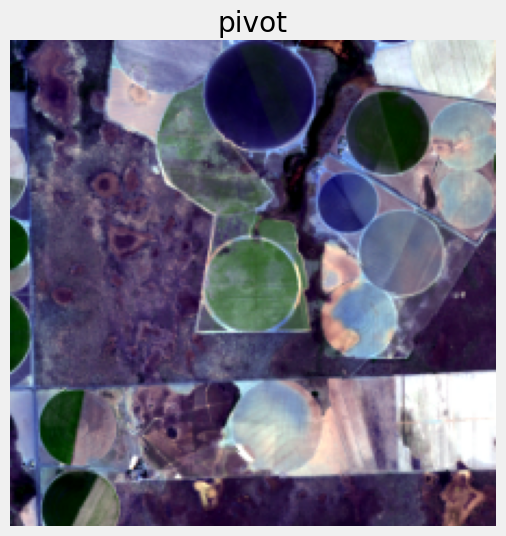

In [ ]:
i=100
plt.figure(figsize=[6,6])
plt.title(class_list[Y[i]])
plt.imshow(X[i,:,:,:])
plt.axis('off')

Vamos dividir os dados em treinamento e teste:

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=10)

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten
from keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Dropout, Activation, ZeroPadding2D
from keras.regularizers import l2
#from tensorflow.keras.optimizers.legacy import Adam
from keras.optimizers import Adam

In [ ]:
Model = Sequential()
Model.add(Conv2D(32,(3,3), kernel_initializer="he_normal", padding='same', input_shape=(x_train.shape[1:])))
Model.add(Activation('relu'))
Model.add(MaxPooling2D(pool_size=(2,2),strides=2))
Model.add(BatchNormalization())
Model.add(Dropout(0.25))
Model.add(Conv2D(64,(3,3), kernel_initializer="he_normal", padding='same'))
Model.add(Activation('relu'))
Model.add(MaxPooling2D(pool_size=(2,2),strides=2))
Model.add(BatchNormalization())
Model.add(Dropout(0.25))
Model.add(Conv2D(128,(3,3), kernel_initializer="he_normal", padding='same'))
Model.add(Activation('relu'))
Model.add(MaxPooling2D(pool_size=(2,2),strides=2))
Model.add(Flatten())
Model.add(Dense(128))
Model.add(Activation('relu'))
Model.add(Dropout(0.25))
Model.add(Dense(32))
Model.add(Activation('relu'))
Model.add(Dense(1))
Model.add(Activation('sigmoid'))
Model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate = 1e-5), metrics=['accuracy'])
Model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,942,977 (49.37 MB)

 Trainable params: 12,942,785 (49.37 MB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
history = Model.fit(x = x_train, y= y_train, batch_size=32, epochs=50, verbose=1, shuffle=True, validation_split=0.25)

Epoch 1/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 19s 225ms/step - accuracy: 0.6301 - loss: 0.9671 - val_accuracy: 0.5945 - val_loss: 0.6616
Epoch 2/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.7754 - loss: 0.5143 - val_accuracy: 0.7654 - val_loss: 0.5052
Epoch 3/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.8087 - loss: 0.4350 - val_accuracy: 0.8200 - val_loss: 0.4184
Epoch 4/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.8023 - loss: 0.4773 - val_accuracy: 0.7631 - val_loss: 0.4921
Epoch 5/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.8510 - loss: 0.3495 - val_accuracy: 0.7973 - val_loss: 0.4317
Epoch 6/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.8832 - loss: 0.2987 - val_accuracy: 0.8679 - val_loss: 0.3641
Epoch 7/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.8838 - loss: 0.2884 - val_accuracy: 0.7790 - val_loss: 0.4470
Epoch 8/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.8954 - loss: 0.2485 - val_accuracy: 0.8269 -

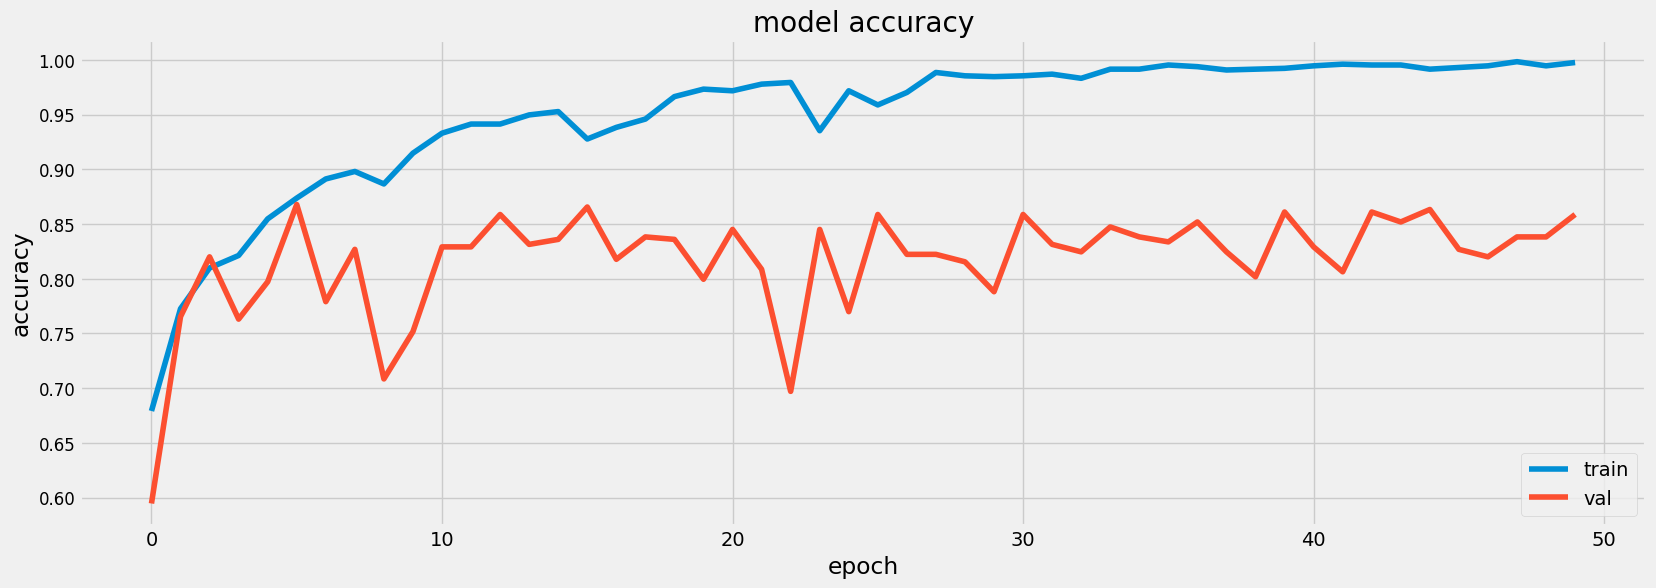

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='lower right')
plt.show()

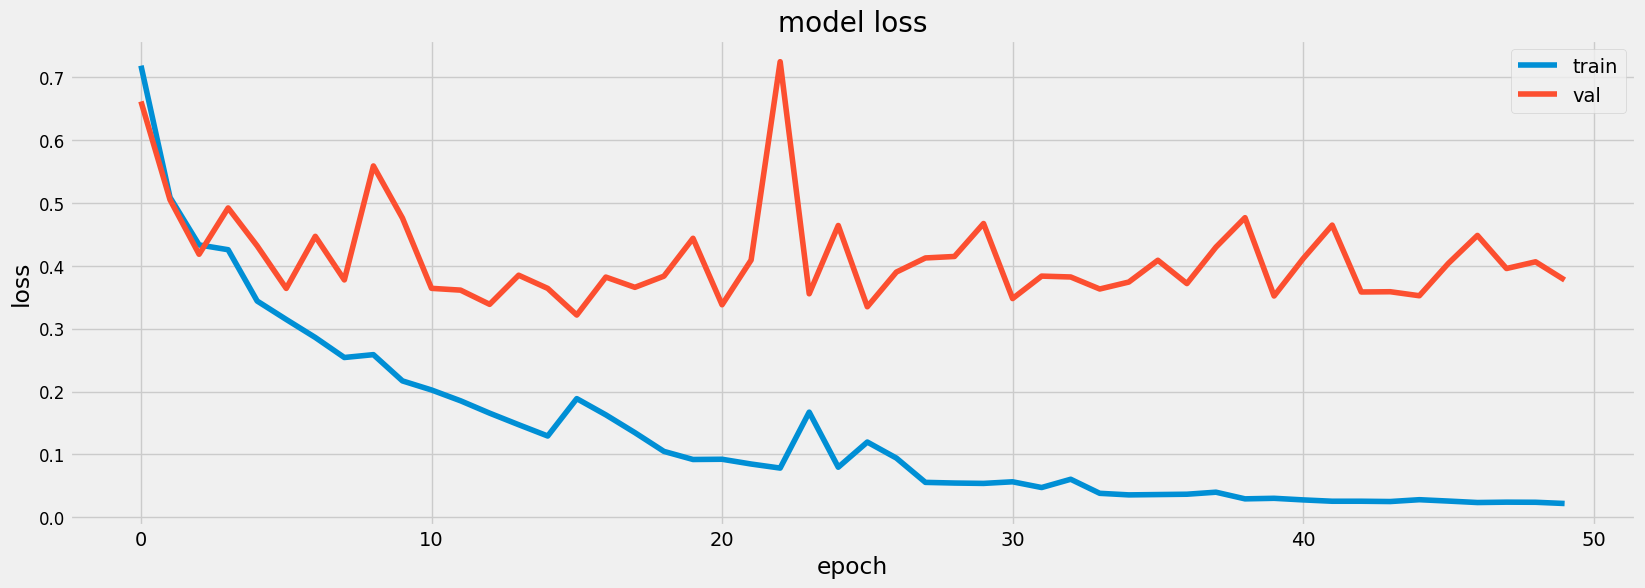

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper right')
plt.show()